# Unsupervised Learning: Kundensegmentierung im Online Retail Datensatz

In diesem Notebook wird der bereits bereinigte Online-Retail-Datensatz verwendet. Ziel ist es, Kund:innen anhand ihres Kaufverhaltens automatisch in Gruppen zu unterteilen.

Der Ablauf ist bewusst einfach und klar gehalten:

1. Cleaned Dataset laden  
2. Kund:innen-Merkmale berechnen  
3. Daten skalieren  
4. K-Means Clustering durchführen  
5. Cluster interpretieren  
6. Cluster visualisieren  
7. Ergebnisse exportieren

## 1. Bibliotheken importieren

Zuerst werden die benötigten Python-Bibliotheken geladen. Pandas und NumPy werden für die Datenverarbeitung verwendet. Matplotlib erstellt Diagramme. Scikit-learn stellt die Methoden für Skalierung, Clustering und PCA bereit.

In [51]:
# Datenanalyse
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt

# Machine Learning / Unsupervised Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Dendrogramm für hierarchisches Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Diagrammgröße festlegen
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Bereinigten Datensatz laden

Hier wird der Datensatz geladen, der im vorherigen Notebook bereits bereinigt wurde. Dadurch müssen Stornos, negative Mengen oder fehlende Kundennummern nicht erneut entfernt werden.

In [52]:
# Datei einlesen
# parse_dates sorgt dafür, dass InvoiceDate direkt als Datum erkannt wird.
df = pd.read_csv(
    "../data/online_retail_data_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

# Erste fünf Zeilen anzeigen
df.head()

/tmp/ipykernel_41212/3456634273.py:3: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,False
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False


## 3. Überblick über den Datensatz

Mit `shape`, `info()` und `describe()` verschaffen wir uns einen kurzen Überblick über die Daten. So sieht man, wie viele Zeilen und Spalten vorhanden sind und welche Datentypen verwendet werden.

In [53]:
# Anzahl der Zeilen und Spalten anzeigen
df.shape

(397884, 11)

In [54]:
# Informationen zu Spalten und Datentypen anzeigen
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       397884 non-null  object        
 1   StockCode       397754 non-null  str           
 2   Description     397558 non-null  str           
 3   Quantity        397884 non-null  float64       
 4   InvoiceDate     397884 non-null  datetime64[us]
 5   UnitPrice       397884 non-null  float64       
 6   CustomerID      397884 non-null  float64       
 7   Country         397884 non-null  str           
 8   TotalPrice      397884 non-null  float64       
 9   InvoiceMonth    397884 non-null  str           
 10  IsCancellation  397884 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(4), object(1), str(4)
memory usage: 30.7+ MB


In [55]:
# Statistische Kennzahlen der numerischen Spalten anzeigen
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


## 4. Kund:innen-Daten erstellen

Für das Clustering brauchen wir eine Tabelle, in der jede Kundin bzw. jeder Kunde genau einmal vorkommt. Deshalb werden die Transaktionen nach `CustomerID` zusammengefasst.

Für jede Kundin bzw. jeden Kunden berechnen wir:

- Gesamtumsatz
- Anzahl der Bestellungen
- gekaufte Gesamtmenge
- durchschnittlicher Bestellwert
- Anzahl unterschiedlicher Produkte
- Anzahl aktiver Einkaufstage

In [56]:
# Kund:innen-Merkmale aus den Transaktionen berechnen
customer_data = df.groupby("CustomerID").agg(
    total_revenue=("TotalPrice", "sum"),
    number_of_orders=("InvoiceNo", "nunique"),
    total_quantity=("Quantity", "sum"),
    avg_order_value=("TotalPrice", "mean"),
    unique_products=("StockCode", "nunique"),
    active_days=("InvoiceDate", lambda x: x.dt.date.nunique())
).reset_index()

# Erste Zeilen der Kund:innen-Tabelle anzeigen
customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days
0,12346.0,77183.60,1,74215.0,77183.600000,1,1
1,12347.0,4310.00,7,2458.0,23.681319,103,7
2,12348.0,1797.24,4,2341.0,57.975484,22,4
3,12349.0,1757.55,1,631.0,24.076027,73,1
4,12350.0,334.40,1,197.0,19.670588,17,1


## 5. Features für das Clustering auswählen

Für K-Means werden nur numerische Merkmale verwendet. Die `CustomerID` dient nur als Kennung und wird nicht als Merkmal verwendet.

In [57]:
# Merkmale auswählen, die das Kaufverhalten beschreiben
features = [
    "total_revenue",
    "number_of_orders",
    "total_quantity",
    "avg_order_value",
    "unique_products",
    "active_days"
]

X = customer_data[features]

# Ausgewählte Merkmale anzeigen
X.head()

,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days
0,77183.60,1,74215.0,77183.600000,1,1
1,4310.00,7,2458.0,23.681319,103,7
2,1797.24,4,2341.0,57.975484,22,4
3,1757.55,1,631.0,24.076027,73,1
4,334.40,1,197.0,19.670588,17,1


## 6. Log-Transformation und Skalierung

Online-Retail-Daten sind meistens stark schief verteilt: Viele Kund:innen kaufen wenig, einige wenige Kund:innen kaufen sehr viel. Dadurch können extreme Umsatz- oder Mengenwerte das K-Means-Clustering stark beeinflussen.

Deshalb wird zuerst eine Log-Transformation mit `np.log1p()` durchgeführt. Danach werden die Werte mit dem `StandardScaler` skaliert.


In [58]:
# Log-Transformation anwenden
# np.log1p(x) bedeutet log(1 + x).
# Dadurch werden sehr große Werte abgeschwächt, ohne kleine Werte zu verlieren.
X_log = np.log1p(X)

# StandardScaler transformiert die Daten so, dass jedes Merkmal
# ungefähr Mittelwert 0 und Standardabweichung 1 hat.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Skalierte Daten als DataFrame anzeigen
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()


,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days
0,3.706225,-0.955183,3.816653,9.644986,-2.526132,-0.946863
1,1.411843,1.074278,1.329485,0.260812,0.966127,1.193383
2,0.716489,0.386217,1.293900,1.276520,-0.367493,0.467763
3,0.698739,-0.955183,0.337734,0.279312,0.665334,-0.946863
4,-0.618962,-0.955183,-0.509484,0.054033,-0.584142,-0.946863


## 7. Elbow-Methode

Mit der Elbow-Methode wird untersucht, welche Anzahl an Clustern sinnvoll ist. Dabei wird K-Means mit verschiedenen Clusteranzahlen getestet. Ein Knick im Diagramm kann ein Hinweis auf eine geeignete Clusteranzahl sein.

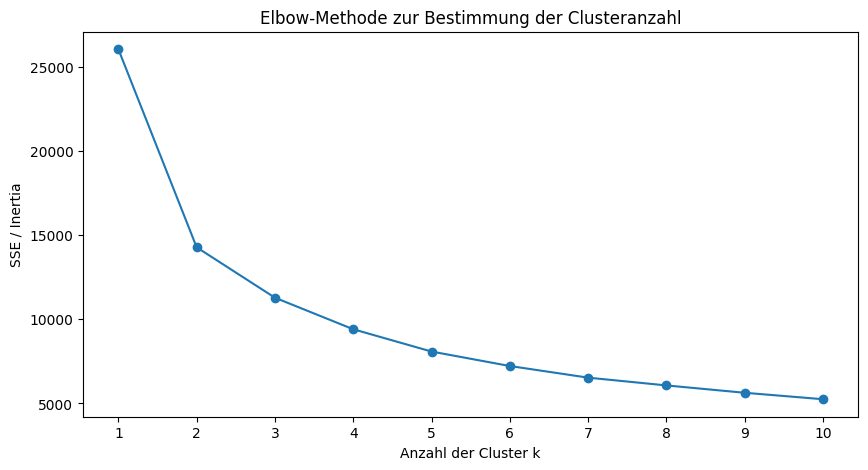

In [59]:
# Sum of Squared Errors für verschiedene k-Werte berechnen
sse = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Elbow-Diagramm erstellen
plt.plot(k_values, sse, marker="o")
plt.title("Elbow-Methode zur Bestimmung der Clusteranzahl")
plt.xlabel("Anzahl der Cluster k")
plt.ylabel("SSE / Inertia")
plt.xticks(k_values)
plt.show()

## 8. Silhouette Score

Der Silhouette Score misst, wie gut die Datenpunkte zu ihrem eigenen Cluster passen und wie gut sie von anderen Clustern getrennt sind. Höhere Werte deuten auf klarere Cluster hin.

In [60]:
# Silhouette Scores für verschiedene Clusteranzahlen berechnen
silhouette_scores = []
k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Silhouette Scores als Tabelle anzeigen
silhouette_df = pd.DataFrame({
    "k": list(k_values_silhouette),
    "silhouette_score": silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.408432
1,3,0.303958
2,4,0.317499
3,5,0.275198
4,6,0.248376
5,7,0.256856
6,8,0.259678
7,9,0.255027
8,10,0.257735


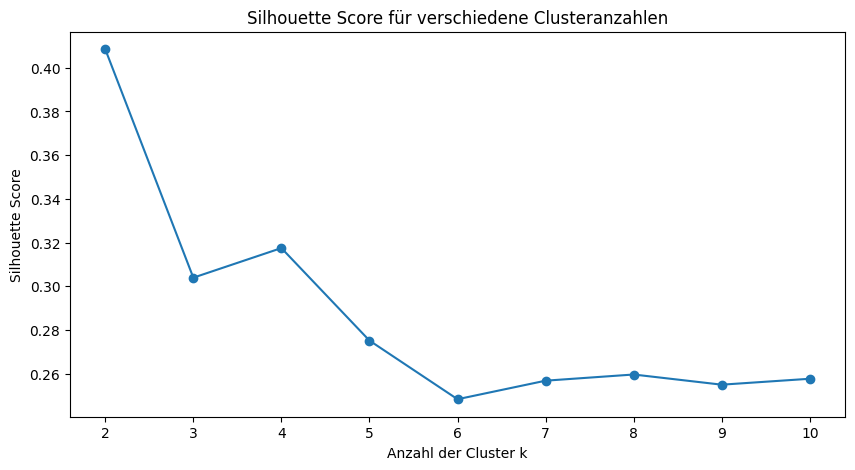

In [61]:
# Silhouette Scores visualisieren
plt.plot(k_values_silhouette, silhouette_scores, marker="o")
plt.title("Silhouette Score für verschiedene Clusteranzahlen")
plt.xlabel("Anzahl der Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(k_values_silhouette)
plt.show()

## 9. K-Means Clustering durchführen

Die Clusteranzahl wird nicht fest geraten, sondern aus dem höchsten Silhouette Score gewählt. Dadurch verwendet das Notebook die Clusteranzahl, die bei diesen Daten die beste Trennung der Kund:innen liefert.

Wichtig: Die Elbow-Methode wird trotzdem vorher betrachtet, weil sie zeigt, ab wann zusätzliche Cluster nur noch wenig Verbesserung bringen.


In [62]:
# Clusteranzahl mit dem höchsten Silhouette Score auswählen
best_k = silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print(f"Gewählte Clusteranzahl: k = {best_k}")

# K-Means Modell erstellen und auf die skalierten Daten anwenden
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customer_data["cluster"] = kmeans.fit_predict(X_scaled)

# Erste Zeilen mit Cluster-Zuordnung anzeigen
customer_data.head()


Gewählte Clusteranzahl: k = 2


,CustomerID,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days,cluster
0,12346.0,77183.60,1,74215.0,77183.600000,1,1,0
1,12347.0,4310.00,7,2458.0,23.681319,103,7,0
2,12348.0,1797.24,4,2341.0,57.975484,22,4,0
3,12349.0,1757.55,1,631.0,24.076027,73,1,1
4,12350.0,334.40,1,197.0,19.670588,17,1,1


## 10. Clustergrößen anzeigen

Hier wird gezeigt, wie viele Kund:innen zu jedem Cluster gehören. Dadurch sieht man, ob die Gruppen ungefähr gleich groß sind oder ob einzelne Segmente deutlich größer sind.

In [63]:
# Anzahl der Kund:innen pro Cluster berechnen
cluster_counts = customer_data["cluster"].value_counts().sort_index()

cluster_counts

cluster
0    1644
1    2694
Name: count, dtype: int64

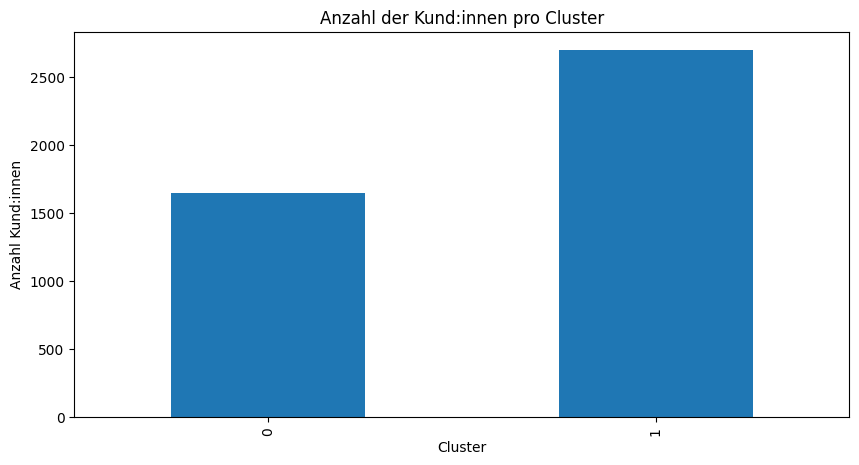

In [64]:
# Clustergrößen als Balkendiagramm darstellen
cluster_counts.plot(kind="bar")
plt.title("Anzahl der Kund:innen pro Cluster")
plt.xlabel("Cluster")
plt.ylabel("Anzahl Kund:innen")
plt.show()

## 11. Cluster interpretieren

Nun werden die Durchschnittswerte der Merkmale pro Cluster berechnet. Dadurch kann man beschreiben, welche Art von Kund:innen in den jeweiligen Clustern enthalten ist.

In [65]:
# Durchschnittliche Merkmale pro Cluster berechnen
cluster_summary = customer_data.groupby("cluster")[features].mean().round(2)

cluster_summary

,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days
cluster,,,,,,
0,4637.01,8.55,2697.75,116.13,117.77,7.57
1,478.16,1.66,271.98,39.19,27.13,1.60


## 12. Interpretation der Cluster

Die folgende Tabelle kann für die Projektarbeit verwendet werden, um die Cluster inhaltlich zu beschreiben. Die genaue Interpretation hängt von den berechneten Durchschnittswerten ab.

Beispiel:

- Cluster mit hohem Umsatz und vielen Bestellungen: wertvolle Stammkund:innen
- Cluster mit wenigen Bestellungen und geringem Umsatz: Gelegenheitskund:innen
- Cluster mit hohem durchschnittlichem Bestellwert: Kund:innen mit größeren Einzelkäufen

In [66]:
# Cluster nach Gesamtumsatz sortieren, um sie leichter interpretieren zu können
cluster_summary.sort_values("total_revenue", ascending=False)

,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days
cluster,,,,,,
0,4637.01,8.55,2697.75,116.13,117.77,7.57
1,478.16,1.66,271.98,39.19,27.13,1.60


## 13. PCA zur Visualisierung

Da das Clustering mit mehreren Merkmalen durchgeführt wird, kann man die Cluster nicht direkt in einem zweidimensionalen Diagramm darstellen. PCA reduziert die Merkmale auf zwei Hauptkomponenten, damit die Cluster visualisiert werden können.

In [67]:
# PCA auf zwei Komponenten reduzieren
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# PCA-Ergebnisse zur Kund:innen-Tabelle hinzufügen
customer_data["pca_1"] = X_pca[:, 0]
customer_data["pca_2"] = X_pca[:, 1]

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,avg_order_value,unique_products,active_days,cluster,pca_1,pca_2
0,12346.0,77183.60,1,74215.0,77183.600000,1,1,0,1.922260,10.340074
1,12347.0,4310.00,7,2458.0,23.681319,103,7,0,2.690622,0.214597
2,12348.0,1797.24,4,2341.0,57.975484,22,4,0,1.213400,1.540718
3,12349.0,1757.55,1,631.0,24.076027,73,1,1,-0.125259,-0.012391
4,12350.0,334.40,1,197.0,19.670588,17,1,1,-1.620494,0.094792


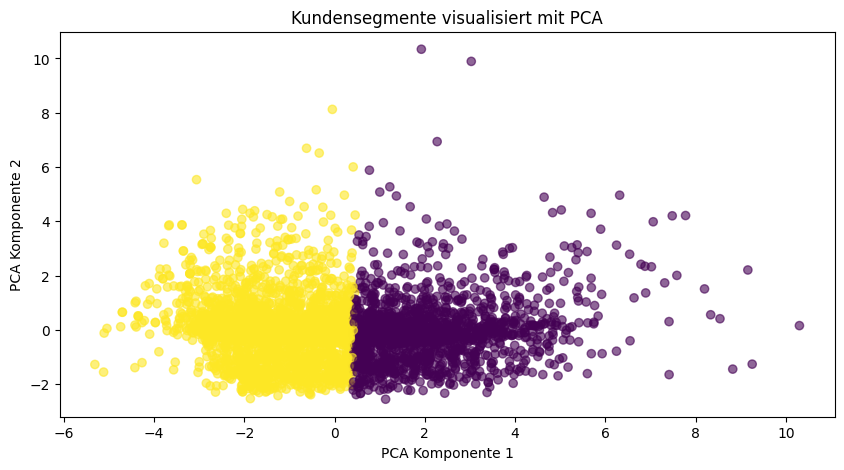

In [68]:
# Cluster im PCA-Diagramm darstellen
plt.scatter(
    customer_data["pca_1"],
    customer_data["pca_2"],
    c=customer_data["cluster"],
    alpha=0.6
)
plt.title("Kundensegmente visualisiert mit PCA")
plt.xlabel("PCA Komponente 1")
plt.ylabel("PCA Komponente 2")
plt.show()

## 14. Erklärte Varianz der PCA

Die erklärte Varianz zeigt, wie viel Information durch die beiden PCA-Komponenten erhalten bleibt.

In [69]:
# Anteil der erklärten Varianz anzeigen
explained_variance = pd.DataFrame({
    "component": ["PCA 1", "PCA 2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

explained_variance

,component,explained_variance_ratio
0,PCA 1,0.679299
1,PCA 2,0.224773


## 15. Hierarchisches Clustering als Vergleich

Als zweite Methode wird hierarchisches Clustering verwendet. Das Dendrogramm zeigt, wie Kund:innen schrittweise zu Gruppen zusammengeführt werden.

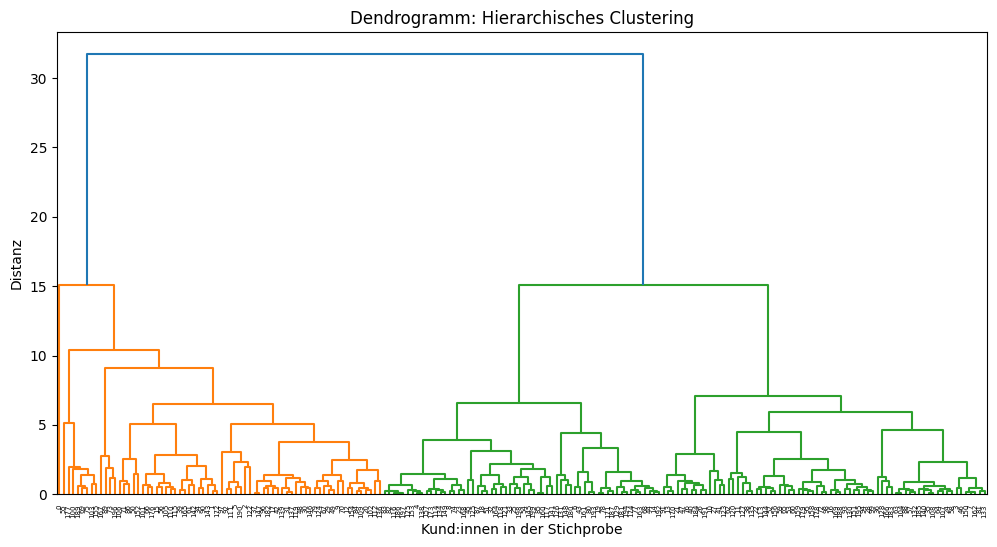

In [70]:
# Für das Dendrogramm wird eine Stichprobe verwendet,
# damit die Darstellung übersichtlich bleibt.
X_sample = X_scaled[:200]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogramm: Hierarchisches Clustering")
plt.xlabel("Kund:innen in der Stichprobe")
plt.ylabel("Distanz")
plt.show()

## 16. Agglomerative Clustering durchführen

Hier wird zusätzlich ein hierarchisches Clustering mit derselben Clusteranzahl wie bei K-Means durchgeführt. Dadurch können die Ergebnisse beider Verfahren miteinander verglichen werden.


In [71]:
# Hierarchisches Clustering mit derselben Clusteranzahl durchführen
agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
customer_data["cluster_hierarchical"] = agglo.fit_predict(X_scaled)

# Vergleich der beiden Clusterverfahren
pd.crosstab(customer_data["cluster"], customer_data["cluster_hierarchical"])


cluster_hierarchical,0,1
cluster,,
0,283,1361
1,2637,57


## 17. Ergebnisse exportieren

Zum Schluss werden die Kund:innen-Segmente gespeichert. Diese Datei kann danach für weitere Analysen oder für die Präsentation verwendet werden.

In [72]:
# Kundensegmente als CSV speichern
customer_data.to_csv(
    "../data/online_retail_customer_segments.csv",
    index=False
)

print("Datei wurde gespeichert: ../data/online_retail_customer_segments.csv")

Datei wurde gespeichert: ../data/online_retail_customer_segments.csv


## 18. Kurzes Fazit

In diesem Notebook wurden Kund:innen mithilfe von Unsupervised Learning segmentiert. Dafür wurden aus den Transaktionsdaten kundenbezogene Merkmale erstellt. Da Retail-Daten häufig stark schief verteilt sind, wurden die Merkmale zuerst log-transformiert und danach skaliert. Anschließend wurde mit Elbow-Methode und Silhouette Score eine passende Clusteranzahl bestimmt und K-Means angewendet.

Die Cluster können genutzt werden, um verschiedene Kundengruppen zu erkennen, zum Beispiel Gelegenheitskund:innen, regelmäßige Kund:innen oder besonders wertvolle Kund:innen.
